In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Model Selection & Evaluation
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,ConfusionMatrixDisplay
)

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
# Statistical testing
from scipy import stats

# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE





### Load Data

In [2]:
# Define paths
artifact_path = Path("preprocessing_artifacts")



USE_FEATURE_FILTERING = False  # Set to False to use all features



audio_features_cols = ['Speechiness', 'Danceability', 'Valence', 'Loudness_norm']
artist_features_cols = ['artist_song_count', 
                        'artist_avg_rank',
                        'artist_best_rank']

temporal_features_cols = ['is_friday_release']


selected_features = audio_features_cols + artist_features_cols + temporal_features_cols

if USE_FEATURE_FILTERING:
    print(f"Selected Features ({len(selected_features)} total):")
    print(f"   Audio Features ({len(audio_features_cols)}): {audio_features_cols}")
    print(f"   Artist Features ({len(artist_features_cols)}): {artist_features_cols}")
    print(f"   Temporal Features ({len(temporal_features_cols)}): {temporal_features_cols}")

# Load Baseline data
X_train_baseline_full = pd.read_csv(artifact_path / "X_train_baseline.csv")
X_val_baseline_full = pd.read_csv(artifact_path / "X_val_baseline.csv")
X_test_baseline_full = pd.read_csv(artifact_path / "X_test_baseline.csv")

# Apply filtering based on configuration
if USE_FEATURE_FILTERING:
    # Filter to only selected features
    X_train_baseline = X_train_baseline_full[selected_features]
    X_val_baseline = X_val_baseline_full[selected_features]
    X_test_baseline = X_test_baseline_full[selected_features]

    # Verify all selected features are present
    missing_features = set(selected_features) - set(X_train_baseline.columns)
    if missing_features:
        print(f" WARNING: Missing features in baseline: {missing_features}")
    else:
        print(f"All {len(selected_features)} selected features found and filtered")
else:
    # Use all features
    X_train_baseline = X_train_baseline_full.copy()
    X_val_baseline = X_val_baseline_full.copy()
    X_test_baseline = X_test_baseline_full.copy()

    print(f"Using all {X_train_baseline.shape[1]} features ")

# Load L1 Selected Features data
X_train_L1 = pd.read_csv(artifact_path / "X_train_L1.csv")
X_val_L1 = pd.read_csv(artifact_path / "X_val_L1.csv")
X_test_L1 = pd.read_csv(artifact_path / "X_test_L1.csv")

# Load PCA data
X_train_pca = pd.read_csv(artifact_path / "X_train_pca.csv")
X_val_pca = pd.read_csv(artifact_path / "X_val_pca.csv")
X_test_pca = pd.read_csv(artifact_path / "X_test_pca.csv")


# Load target variables
y_train = pd.read_csv(artifact_path / "y_train.csv")
y_val = pd.read_csv(artifact_path / "y_val.csv")
y_test = pd.read_csv(artifact_path / "y_test.csv")

# Convert target to binary (if not already)
y_train_array = y_train['popularity_label'].map({'Popular': 1, 'Not Popular': 0}).values
y_val_array = y_val['popularity_label'].map({'Popular': 1, 'Not Popular': 0}).values
y_test_array = y_test['popularity_label'].map({'Popular': 1, 'Not Popular': 0}).values


print(f"Baseline {'(filtered)' if USE_FEATURE_FILTERING else '(all features)'}: X_train={X_train_baseline.shape}, X_val={X_val_baseline.shape},X_test={X_test_baseline.shape}")
print(f"L1 Selection:        X_train={X_train_L1.shape}, X_val={X_val_L1.shape}, X_test={X_test_L1.shape}")
print(f"PCA:                 X_train={X_train_pca.shape}, X_val={X_val_pca.shape},X_test={X_test_pca.shape}")
print(f"Target:              y_train={y_train_array.shape}, y_val={y_val_array.shape}, y_test={y_test_array.shape}")



Using all 20 features 
Baseline (all features): X_train=(6158, 20), X_val=(1414, 20),X_test=(1589, 20)
L1 Selection:        X_train=(6158, 10), X_val=(1414, 10), X_test=(1589, 10)
PCA:                 X_train=(6158, 13), X_val=(1414, 13),X_test=(1589, 13)
Target:              y_train=(6158,), y_val=(1414,), y_test=(1589,)


### Add SMOTE

In [3]:
smote = SMOTE(random_state=42, sampling_strategy='auto')

# SMOTE for Baseline
X_train_baseline_smote, y_train_baseline_smote = smote.fit_resample(X_train_baseline, y_train_array)
print(f"Baseline SMOTE - Original: {X_train_baseline.shape}, After SMOTE: {X_train_baseline_smote.shape}")
print(f"  Class distribution: {np.bincount(y_train_baseline_smote)}")

# SMOTE for L1
X_train_L1_smote, y_train_L1_smote = smote.fit_resample(X_train_L1, y_train_array)
print(f"\nL1 SMOTE - Original: {X_train_L1.shape}, After SMOTE: {X_train_L1_smote.shape}")
print(f"  Class distribution: {np.bincount(y_train_L1_smote)}")

# SMOTE for PCA
X_train_pca_smote, y_train_pca_smote = smote.fit_resample(X_train_pca, y_train_array)
print(f"\nPCA SMOTE - Original: {X_train_pca.shape}, After SMOTE: {X_train_pca_smote.shape}")
print(f"  Class distribution: {np.bincount(y_train_pca_smote)}")


datasets_smote = {
    'Baseline': (X_train_baseline_smote, X_val_baseline, y_train_baseline_smote),
    'L1': (X_train_L1_smote, X_val_L1, y_train_L1_smote),
    'PCA': (X_train_pca_smote, X_val_pca, y_train_pca_smote)
}



Baseline SMOTE - Original: (6158, 20), After SMOTE: (8620, 20)
  Class distribution: [4310 4310]

L1 SMOTE - Original: (6158, 10), After SMOTE: (8620, 10)
  Class distribution: [4310 4310]

PCA SMOTE - Original: (6158, 13), After SMOTE: (8620, 13)
  Class distribution: [4310 4310]


### Set up models

In [4]:
def get_models_for_tuning():
    return {
        'Logistic Regression': LogisticRegression(
            penalty='l2', max_iter=2000, random_state=42
        ),
        'SVM (Linear)': SVC(
            kernel='linear', probability=True,
            random_state=42, max_iter=3000
        ),
        'SVM (RBF)': SVC(
            kernel='rbf', probability=True,
            random_state=42, max_iter=3000
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200,random_state=42, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'XGBoost': XGBClassifier(
            eval_metric='logloss', random_state=42, n_jobs=-1, tree_method='hist'
        )
    }

In [5]:
param_grids = {
    'Logistic Regression': {
        'C': [0.05, 0.1, 1, 5, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    'SVM (Linear)': {
        'C': [0.1, 1, 10]
    },
    'SVM (RBF)': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.01, 0.1]
    },
    'Random Forest': {
        'n_estimators': [10,20,50,100, 200, 400],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'n_estimators': [10,20,50,100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [2, 3, 4]
    },
    'XGBoost': {
        'n_estimators': [10,20,50,100, 200, 400],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [4, 6, 8],
        'subsample': [0.7, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.9, 1.0],
        'reg_lambda': [0.5, 1.0, 2.0],
        'reg_alpha': [0, 0.1, 0.5]
    }
}

In [6]:
def tune_model_cv(model_name, model, X_train, y_train, X_val, y_val, param_grid, cv=5):
    print(f"Tuning: {model_name}")
    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
  
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv_strategy,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    
  
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    
    # Validation predictions
    y_val_pred = best_model.predict(X_val)
    y_val_proba = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, 'predict_proba') else None
    

    results = {
        'model_name': model_name,
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'best_model': best_model,
        'val_accuracy': accuracy_score(y_val, y_val_pred),
        'val_precision': precision_score(y_val, y_val_pred, zero_division=0),
        'val_recall': recall_score(y_val, y_val_pred),
        'val_f1': f1_score(y_val, y_val_pred),
        'val_roc_auc': roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else None
    }
    

    print(f"\n Best Parameters: {results['best_params']}")
    print(f"   CV ROC-AUC: {results['best_cv_score']:.4f}")
    print(f"   Val Accuracy: {results['val_accuracy']:.4f}")
    print(f"   Val F1-Score: {results['val_f1']:.4f}")
    print(f"   Val ROC-AUC: {results['val_roc_auc']:.4f}" if results['val_roc_auc'] else "")
    
    return results


In [7]:

FEATURE_SET = 'Baseline' 

# Select appropriate datasets
if FEATURE_SET == 'Baseline':
    X_train_selected = X_train_baseline_smote
    X_val_selected = X_val_baseline
    y_train_selected = y_train_baseline_smote
elif FEATURE_SET == 'L1':
    X_train_selected = X_train_L1_smote
    X_val_selected = X_val_L1
    y_train_selected = y_train_L1_smote
else:  # PCA
    X_train_selected = X_train_pca_smote
    X_val_selected = X_val_pca
    y_train_selected = y_train_pca_smote

print(f"Training set: {X_train_selected.shape}")
print(f"Validation set: {X_val_selected.shape}")


models_dict = get_models_for_tuning()


all_results = []
best_models_dict = {}


for model_name, model in models_dict.items():
    results = tune_model_cv(
        model_name=model_name,
        model=model,
        X_train=X_train_selected,
        y_train=y_train_selected,
        X_val=X_val_selected,
        y_val=y_val_array,
        param_grid=param_grids[model_name],
        cv=5
    )
    
    all_results.append(results)
    best_models_dict[model_name] = results['best_model']

#
results_summary = pd.DataFrame([
    {
        'Model': r['model_name'],
        'CV ROC-AUC': r['best_cv_score'],
        'Val Accuracy': r['val_accuracy'],
        'Val Precision': r['val_precision'],
        'Val Recall': r['val_recall'],
        'Val F1': r['val_f1'],
        'Val ROC-AUC': r['val_roc_auc']
    }
    for r in all_results
]).sort_values('Val F1', ascending=False)


display(results_summary)

Training set: (8620, 20)
Validation set: (1414, 20)
Tuning: Logistic Regression
Fitting 5 folds for each of 10 candidates, totalling 50 fits

 Best Parameters: {'C': 0.05, 'solver': 'liblinear'}
   CV ROC-AUC: 0.7432
   Val Accuracy: 0.6506
   Val F1-Score: 0.3634
   Val ROC-AUC: 0.5799
Tuning: SVM (Linear)
Fitting 5 folds for each of 3 candidates, totalling 15 fits

 Best Parameters: {'C': 0.1}
   CV ROC-AUC: 0.7370
   Val Accuracy: 0.4569
   Val F1-Score: 0.4499
   Val ROC-AUC: 0.5898
Tuning: SVM (RBF)
Fitting 5 folds for each of 9 candidates, totalling 45 fits

 Best Parameters: {'C': 10, 'gamma': 0.1}
   CV ROC-AUC: 0.8408
   Val Accuracy: 0.6973
   Val F1-Score: 0.2517
   Val ROC-AUC: 0.6149
Tuning: Random Forest
Fitting 5 folds for each of 144 candidates, totalling 720 fits

 Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
   CV ROC-AUC: 0.9082
   Val Accuracy: 0.6754
   Val F1-Score: 0.3357
   Val R

,Model,CV ROC-AUC,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC
4,Gradient Boosting,0.896544,0.630127,0.388889,0.543860,0.453501,0.649998
1,SVM (Linear),0.736996,0.456860,0.314945,0.786967,0.449857,0.589759
5,XGBoost,0.911835,0.635785,0.388031,0.503759,0.438386,0.655033
0,Logistic Regression,0.743234,0.650636,0.374005,0.353383,0.363402,0.579884
3,Random Forest,0.908209,0.675389,0.397260,0.290727,0.335745,0.640688
2,SVM (RBF),0.840827,0.697313,0.416185,0.180451,0.251748,0.614851


### Visualize result

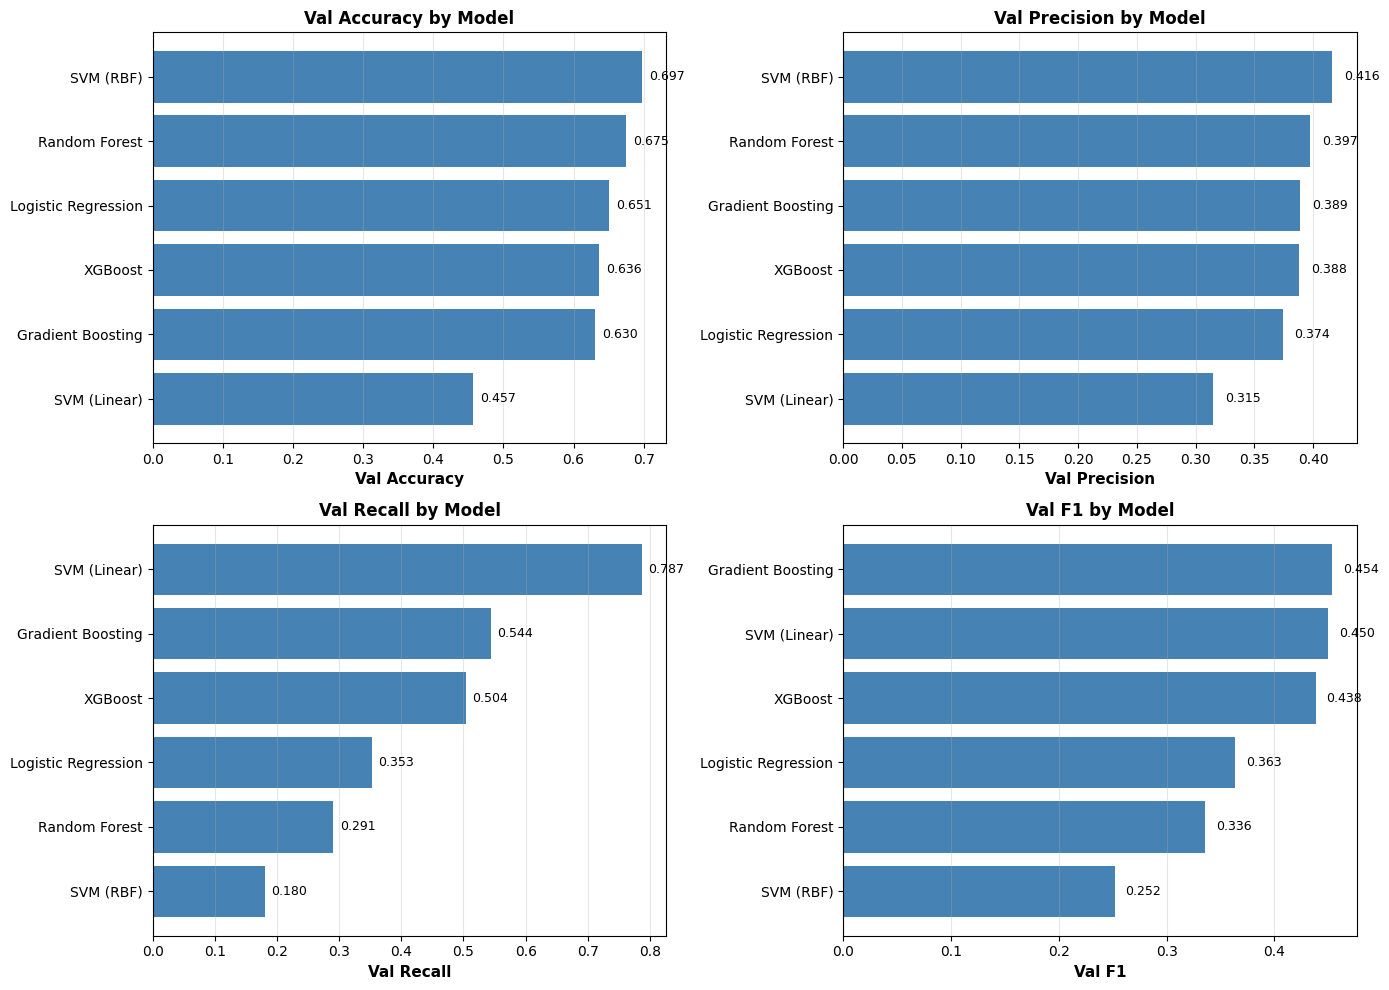

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Val Accuracy', 'Val Precision', 'Val Recall', 'Val F1']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    data_sorted = results_summary.sort_values(metric, ascending=True)
    
    ax.barh(data_sorted['Model'], data_sorted[metric], color='steelblue')
    ax.set_xlabel(metric, fontsize=11, weight='bold')
    ax.set_title(f'{metric} by Model', fontsize=12, weight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(data_sorted[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
def tune_one_model(name, model, Xtr, ytr, Xva, yva, scoring='roc_auc'):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    gs = GridSearchCV(model, param_grids[name], scoring=scoring, cv=cv, n_jobs=-1, refit=True, verbose=0)
    gs.fit(Xtr, ytr)
    best_est = gs.best_estimator_

    if hasattr(best_est, 'predict_proba'):
        proba = best_est.predict_proba(Xva)[:, 1]
    elif hasattr(best_est, 'decision_function'):
        proba = best_est.decision_function(Xva)
    else:
        proba = None

    pred_05 = best_est.predict(Xva)
    roc = roc_auc_score(yva, proba) if proba is not None else np.nan
    f1_05 = f1_score(yva, pred_05)
    acc_05 = accuracy_score(yva, pred_05)
    pre_05 = precision_score(yva, pred_05, zero_division=0)
    rec_05 = recall_score(yva, pred_05)

    best_t, f1_best = 0.5, f1_05

    return {
        'best_estimator': best_est, 'best_params': gs.best_params_,
        'val_roc_auc': roc, 'val_f1@0.5': f1_05, 'val_acc@0.5': acc_05,
        'val_prec@0.5': pre_05, 'val_recall@0.5': rec_05,
        'best_t': best_t, 'val_f1@best_t': f1_best
    }

In [10]:
def run_all_tuning(datasets_smote, y_val_array, scoring='roc_auc'):
    models = get_models_for_tuning()
    rows, best_models = [], {}
    for feat_name, (Xtr, Xva, ytr) in datasets_smote.items():
        for mname, model in models.items():
            print(f"{feat_name} | {mname} ")
            out = tune_one_model(mname, model, Xtr, ytr, Xva, y_val_array, scoring=scoring)
            rows.append({'feature_set': feat_name, 'model': mname, 'best_params': out['best_params'],
                         'val_roc_auc': out['val_roc_auc'], 'val_f1@0.5': out['val_f1@0.5'],
                         'val_f1@best_t': out['val_f1@best_t'], 'best_t': out['best_t'],
                         'val_acc@0.5': out['val_acc@0.5'], 'val_prec@0.5': out['val_prec@0.5'],
                         'val_recall@0.5': out['val_recall@0.5']})
            best_models[(feat_name, mname)] = (out['best_estimator'], out['best_t'])
    return pd.DataFrame(rows).sort_values(by=['val_roc_auc','val_f1@best_t'], ascending=False), best_models

results_df, best_models = run_all_tuning(datasets_smote, y_val_array, scoring='roc_auc')
results_df

Baseline | Logistic Regression 
Baseline | SVM (Linear) 
Baseline | SVM (RBF) 
Baseline | Random Forest 
Baseline | Gradient Boosting 
Baseline | XGBoost 
L1 | Logistic Regression 
L1 | SVM (Linear) 
L1 | SVM (RBF) 
L1 | Random Forest 
L1 | Gradient Boosting 
L1 | XGBoost 
PCA | Logistic Regression 
PCA | SVM (Linear) 
PCA | SVM (RBF) 
PCA | Random Forest 
PCA | Gradient Boosting 
PCA | XGBoost 


,feature_set,model,best_params,val_roc_auc,val_f1@0.5,val_f1@best_t,best_t,val_acc@0.5,val_prec@0.5,val_recall@0.5
5,Baseline,XGBoost,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.655033,0.438386,0.438386,0.5,0.635785,0.388031,0.503759
4,Baseline,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_esti...",0.649998,0.453501,0.453501,0.5,0.630127,0.388889,0.543860
3,Baseline,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.640688,0.335745,0.335745,0.5,0.675389,0.397260,0.290727
9,L1,Random Forest,"{'max_depth': None, 'max_features': 'log2', 'm...",0.622917,0.337382,0.337382,0.5,0.652758,0.365497,0.313283
10,L1,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_esti...",0.617835,0.349296,0.349296,0.5,0.673267,0.398714,0.310777
2,Baseline,SVM (RBF),"{'C': 10, 'gamma': 0.1}",0.614851,0.251748,0.251748,0.5,0.697313,0.416185,0.180451
11,L1,XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.612404,0.351245,0.351245,0.5,0.649929,0.368132,0.335840
8,L1,SVM (RBF),"{'C': 1, 'gamma': 'scale'}",0.607604,0.368564,0.368564,0.5,0.670438,0.401180,0.340852
16,PCA,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_esti...",0.606114,0.251724,0.251724,0.5,0.693069,0.403315,0.182957
15,PCA,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.600440,0.182927,0.182927,0.5,0.715700,0.483871,0.112782


In [11]:
results_df.sort_index()

,feature_set,model,best_params,val_roc_auc,val_f1@0.5,val_f1@best_t,best_t,val_acc@0.5,val_prec@0.5,val_recall@0.5
0,Baseline,Logistic Regression,"{'C': 0.05, 'solver': 'liblinear'}",0.579884,0.363402,0.363402,0.5,0.650636,0.374005,0.353383
1,Baseline,SVM (Linear),{'C': 0.1},0.589759,0.449857,0.449857,0.5,0.456860,0.314945,0.786967
2,Baseline,SVM (RBF),"{'C': 10, 'gamma': 0.1}",0.614851,0.251748,0.251748,0.5,0.697313,0.416185,0.180451
3,Baseline,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.640688,0.335745,0.335745,0.5,0.675389,0.397260,0.290727
4,Baseline,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_esti...",0.649998,0.453501,0.453501,0.5,0.630127,0.388889,0.543860
5,Baseline,XGBoost,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.655033,0.438386,0.438386,0.5,0.635785,0.388031,0.503759
6,L1,Logistic Regression,"{'C': 0.05, 'solver': 'liblinear'}",0.577746,0.372624,0.372624,0.5,0.649929,0.376923,0.368421
7,L1,SVM (Linear),{'C': 0.1},0.591237,0.395515,0.395515,0.5,0.580622,0.333333,0.486216
8,L1,SVM (RBF),"{'C': 1, 'gamma': 'scale'}",0.607604,0.368564,0.368564,0.5,0.670438,0.401180,0.340852
9,L1,Random Forest,"{'max_depth': None, 'max_features': 'log2', 'm...",0.622917,0.337382,0.337382,0.5,0.652758,0.365497,0.313283


In [12]:
pd.set_option('display.max_colwidth', None)  

results_df[['feature_set', 'model', 'best_params']].sort_index()

,feature_set,model,best_params
0,Baseline,Logistic Regression,"{'C': 0.05, 'solver': 'liblinear'}"
1,Baseline,SVM (Linear),{'C': 0.1}
2,Baseline,SVM (RBF),"{'C': 10, 'gamma': 0.1}"
3,Baseline,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}"
4,Baseline,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}"
5,Baseline,XGBoost,"{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.9}"
6,L1,Logistic Regression,"{'C': 0.05, 'solver': 'liblinear'}"
7,L1,SVM (Linear),{'C': 0.1}
8,L1,SVM (RBF),"{'C': 1, 'gamma': 'scale'}"
9,L1,Random Forest,"{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}"


In [13]:
df = results_df[['feature_set', 'model', 'best_params']]
table = df.pivot(index='feature_set', columns='model', values='best_params')
table = table.fillna("-")

table

model,Gradient Boosting,Logistic Regression,Random Forest,SVM (Linear),SVM (RBF),XGBoost
feature_set,,,,,,
Baseline,"{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}","{'C': 0.05, 'solver': 'liblinear'}","{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}",{'C': 0.1},"{'C': 10, 'gamma': 0.1}","{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.9}"
L1,"{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}","{'C': 0.05, 'solver': 'liblinear'}","{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}",{'C': 0.1},"{'C': 1, 'gamma': 'scale'}","{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 0.9}"
PCA,"{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}","{'C': 10, 'solver': 'lbfgs'}","{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}",{'C': 0.1},"{'C': 10, 'gamma': 0.1}","{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 0.9}"


### Choose the best model for each feature set

In [14]:
metric_col = 'val_f1@0.5' if 'val_f1@0.5' in results_df.columns else 'val_roc_auc'
winners = (
    results_df
    .sort_values(['feature_set', metric_col], ascending=[True, False])
    .groupby('feature_set', as_index=False)
    .first()
)
display(winners[['feature_set','model','best_params',metric_col,'best_t']])



,feature_set,model,best_params,val_f1@0.5,best_t
0,Baseline,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}",0.453501,0.5
1,L1,SVM (Linear),{'C': 0.1},0.395515,0.5
2,PCA,SVM (Linear),{'C': 0.1},0.446244,0.5


In [15]:
test_maps = {'Baseline': X_test_baseline, 'L1': X_test_L1, 'PCA': X_test_pca}

rows = []
for _, row in winners.iterrows():
    feat, model_name = row['feature_set'], row['model']
    best_est, _ = best_models[(feat, model_name)]
    Xte = test_maps[feat]

    proba = best_est.predict_proba(Xte)[:, 1]
    y_pred = (proba >= 0.5).astype(int)

    rows.append({
        'feature_set': feat,
        'model': model_name,
        'test_acc@0.5':   accuracy_score(y_test_array, y_pred),
        'test_prec@0.5':  precision_score(y_test_array, y_pred, zero_division=0),
        'test_recall@0.5':recall_score(y_test_array, y_pred),
        'test_f1@0.5':    f1_score(y_test_array, y_pred),
        'test_roc_auc':   roc_auc_score(y_test_array, proba),
    })

test_results_top3 = pd.DataFrame(rows).sort_values('test_f1@0.5', ascending=False)
display(test_results_top3)

,feature_set,model,test_acc@0.5,test_prec@0.5,test_recall@0.5,test_f1@0.5,test_roc_auc
2,PCA,SVM (Linear),0.443046,0.297774,0.714922,0.420432,0.532420
0,Baseline,Gradient Boosting,0.539962,0.276190,0.387528,0.322521,0.497321
1,L1,SVM (Linear),0.602266,0.305732,0.320713,0.313043,0.524740


### Choose top 5 the best models

In [16]:
top3_overall = (
    results_df
    .sort_values(by='val_f1@best_t', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

print("Top 5 Best Models Overall (from Validation):")
display(top3_overall[['feature_set', 'model', 'val_f1@best_t', 'val_roc_auc', 'best_t']])

Top 5 Best Models Overall (from Validation):


,feature_set,model,val_f1@best_t,val_roc_auc,best_t
0,Baseline,Gradient Boosting,0.453501,0.649998,0.5
1,Baseline,SVM (Linear),0.449857,0.589759,0.5
2,PCA,SVM (Linear),0.446244,0.592678,0.5
3,Baseline,XGBoost,0.438386,0.655033,0.5
4,L1,SVM (Linear),0.395515,0.591237,0.5


### Test model

In [17]:
test_maps = {'Baseline': X_test_baseline, 'L1': X_test_L1, 'PCA': X_test_pca}

rows = []
for _, row in top3_overall.iterrows():
    feat, model_name = row['feature_set'], row['model']
    best_est, _ = best_models[(feat, model_name)]
    Xte = test_maps[feat]

    proba = best_est.predict_proba(Xte)[:, 1]
    y_pred = (proba >= 0.5).astype(int)

    rows.append({
        'feature_set': feat,
        'model': model_name,
        'test_acc@0.5':   accuracy_score(y_test_array, y_pred),
        'test_prec@0.5':  precision_score(y_test_array, y_pred, zero_division=0),
        'test_recall@0.5':recall_score(y_test_array, y_pred),
        'test_f1@0.5':    f1_score(y_test_array, y_pred),
        'test_roc_auc':   roc_auc_score(y_test_array, proba),
    })

test_results_top3 = pd.DataFrame(rows).sort_values('test_f1@0.5', ascending=False)
display(test_results_top3)

,feature_set,model,test_acc@0.5,test_prec@0.5,test_recall@0.5,test_f1@0.5,test_roc_auc
1,Baseline,SVM (Linear),0.429830,0.300087,0.763920,0.430905,0.531045
2,PCA,SVM (Linear),0.443046,0.297774,0.714922,0.420432,0.532420
0,Baseline,Gradient Boosting,0.539962,0.276190,0.387528,0.322521,0.497321
4,L1,SVM (Linear),0.602266,0.305732,0.320713,0.313043,0.524740
3,Baseline,XGBoost,0.544997,0.270134,0.358575,0.308134,0.496013


### Show all results

In [18]:
test_maps = {'Baseline': X_test_baseline, 'L1': X_test_L1, 'PCA': X_test_pca}
train_maps = {'Baseline': X_train_baseline_smote, 'L1': X_train_L1_smote, 'PCA': X_train_pca_smote}
val_maps = {'Baseline': X_val_baseline, 'L1': X_val_L1, 'PCA': X_val_pca}
train_y_maps = {'Baseline': y_train_baseline_smote, 'L1': y_train_L1_smote, 'PCA': y_train_pca_smote}

error_rows = []

for _, row in results_df.iterrows():
    feat = row['feature_set']
    model_name = row['model']
    best_params = row['best_params']
    # Get the trained model
    best_est, _ = best_models[(feat, model_name)]
    
    # Get datasets
    X_train_set = train_maps[feat]
    X_val_set = val_maps[feat]
    X_test_set = test_maps[feat]
    y_train_set = train_y_maps[feat]
    
    # Train predictions
    y_train_pred = best_est.predict(X_train_set)
    train_acc = accuracy_score(y_train_set, y_train_pred)
    train_f1 = f1_score(y_train_set, y_train_pred)
    
    # Validation predictions
    y_val_pred = best_est.predict(X_val_set)
    val_acc = accuracy_score(y_val_array, y_val_pred)
    val_f1 = f1_score(y_val_array, y_val_pred)
    
    # Test predictions
    y_test_pred = best_est.predict(X_test_set)
    test_acc = accuracy_score(y_test_array, y_test_pred)
    test_f1 = f1_score(y_test_array, y_test_pred)
    
    error_rows.append({
        'Feature Set': feat,
        'Model': model_name,
        'best_params': best_params,
        'Train Error': 1 - train_acc,
        'Val Error': 1 - val_acc,
        'Test Error': 1 - test_acc,
        'Train F1': train_f1,
        'Val F1': val_f1,
        'Test F1': test_f1,
        'Overfit Gap (Val-Train)': (1 - val_acc) - (1 - train_acc),
        'Generalization Gap (Test-Val)': (1 - test_acc) - (1 - val_acc)
    })

error_df = pd.DataFrame(error_rows)
display(error_df)
 

,Feature Set,Model,best_params,Train Error,Val Error,Test Error,Train F1,Val F1,Test F1,Overfit Gap (Val-Train),Generalization Gap (Test-Val)
0,Baseline,XGBoost,"{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.9}",0.009745,0.364215,0.455003,0.990239,0.438386,0.308134,0.354470,0.090788
1,Baseline,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}",0.078074,0.369873,0.460038,0.921699,0.453501,0.322521,0.291798,0.090165
2,Baseline,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}",0.001972,0.324611,0.361233,0.998028,0.335745,0.262211,0.322639,0.036622
3,L1,Random Forest,"{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}",0.001972,0.347242,0.363751,0.998029,0.337382,0.253230,0.345270,0.016509
4,L1,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}",0.085499,0.326733,0.378225,0.913751,0.349296,0.249688,0.241234,0.051493
5,Baseline,SVM (RBF),"{'C': 10, 'gamma': 0.1}",0.141647,0.302687,0.292008,0.863743,0.251748,0.041322,0.161040,-0.010680
6,L1,XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 0.9}",0.008585,0.350071,0.377596,0.991407,0.351245,0.242424,0.341486,0.027525
7,L1,SVM (RBF),"{'C': 1, 'gamma': 'scale'}",0.261717,0.329562,0.315922,0.772351,0.368564,0.122378,0.067845,-0.013640
8,PCA,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}",0.097680,0.306931,0.319698,0.906111,0.251724,0.161716,0.209251,0.012767
9,PCA,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}",0.001972,0.284300,0.285085,0.998029,0.182927,0.017354,0.282328,0.000785


### Result for 5 best model

In [ ]:

# COMPUTE ERROR METRICS FOR TOP MODELS


test_maps = {'Baseline': X_test_baseline, 'L1': X_test_L1, 'PCA': X_test_pca}
train_maps = {'Baseline': X_train_baseline_smote, 'L1': X_train_L1_smote, 'PCA': X_train_pca_smote}
val_maps = {'Baseline': X_val_baseline, 'L1': X_val_L1, 'PCA': X_val_pca}
train_y_maps = {'Baseline': y_train_baseline_smote, 'L1': y_train_L1_smote, 'PCA': y_train_pca_smote}

error_rows = []

for _, row in top3_overall.iterrows():
    feat = row['feature_set']
    model_name = row['model']
    
    # Get the trained model
    best_est, _ = best_models[(feat, model_name)]
    
    # Get datasets
    X_train_set = train_maps[feat]
    X_val_set = val_maps[feat]
    X_test_set = test_maps[feat]
    y_train_set = train_y_maps[feat]
    
    # Train predictions
    y_train_pred = best_est.predict(X_train_set)
    train_acc = accuracy_score(y_train_set, y_train_pred)
    train_f1 = f1_score(y_train_set, y_train_pred)
    
    # Validation predictions
    y_val_pred = best_est.predict(X_val_set)
    val_acc = accuracy_score(y_val_array, y_val_pred)
    val_f1 = f1_score(y_val_array, y_val_pred)
    
    # Test predictions
    y_test_pred = best_est.predict(X_test_set)
    test_acc = accuracy_score(y_test_array, y_test_pred)
    test_f1 = f1_score(y_test_array, y_test_pred)
    
    error_rows.append({
        'Feature Set': feat,
        'Model': model_name,
        'best_para'
        'Train Error': 1 - train_acc,
        'Val Error': 1 - val_acc,
        'Test Error': 1 - test_acc,
        'Train F1': train_f1,
        'Val F1': val_f1,
        'Test F1': test_f1,
        'Overfit Gap (Val-Train)': (1 - val_acc) - (1 - train_acc),
        'Generalization Gap (Test-Val)': (1 - test_acc) - (1 - val_acc)
    })

error_df = pd.DataFrame(error_rows)
display(error_df)
 

,Feature Set,Model,best_paraTrain Error,Val Error,Test Error,Train F1,Val F1,Test F1,Overfit Gap (Val-Train),Generalization Gap (Test-Val)
0,Baseline,Gradient Boosting,0.078074,0.369873,0.460038,0.921699,0.453501,0.322521,0.291798,0.090165
1,Baseline,SVM (Linear),0.383991,0.543140,0.578351,0.715831,0.449857,0.430254,0.159149,0.035211
2,PCA,SVM (Linear),0.370418,0.531825,0.560101,0.723765,0.446244,0.419817,0.161407,0.028276
3,Baseline,XGBoost,0.009745,0.364215,0.455003,0.990239,0.438386,0.308134,0.354470,0.090788
4,L1,SVM (Linear),0.332831,0.419378,0.414726,0.734573,0.395515,0.329603,0.086547,-0.004651


### Hypothesis Test

In [20]:

svm_models = {
    'SVM Baseline': best_models[('Baseline', 'SVM (Linear)')][0],
    'SVM + L1': best_models[('L1', 'SVM (Linear)')][0],
    'SVM + PCA': best_models[('PCA', 'SVM (Linear)')][0]
}


datasets = {
    'SVM Baseline': (X_train_baseline_smote, y_train_baseline_smote),
    'SVM + L1': (X_train_L1_smote, y_train_L1_smote),
    'SVM + PCA': (X_train_pca_smote, y_train_pca_smote)
}


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in svm_models.items():
    print(f"Running Stratified CV for {name}")
    
    X_tr, y_tr = datasets[name]
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_tr, y_tr), 1):
        # Split data
        X_fold_train = X_tr.iloc[train_idx] if hasattr(X_tr, 'iloc') else X_tr[train_idx]
        X_fold_val = X_tr.iloc[val_idx] if hasattr(X_tr, 'iloc') else X_tr[val_idx]
        y_fold_train = y_tr[train_idx]
        y_fold_val = y_tr[val_idx]
        
        # Clone model to avoid refitting the same instance
        from sklearn.base import clone
        model_clone = clone(model)
        
        # Train and predict
        model_clone.fit(X_fold_train, y_fold_train)
        y_pred = model_clone.predict(X_fold_val)
        fold_f1 = f1_score(y_fold_val, y_pred)
        fold_scores.append(fold_f1)
        
        print(f"   Fold {fold}: F1 = {fold_f1:.4f}")
    
    cv_results[name] = np.array(fold_scores)
    print(f"   Mean: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")





print("Test 1: SVM Baseline vs SVM + L1")
t_stat, p_value = stats.ttest_rel(
    cv_results['SVM Baseline'], 
    cv_results['SVM + L1']
)
print(f"   Baseline: {cv_results['SVM Baseline'].mean():.4f} ± {cv_results['SVM Baseline'].std():.4f}")
print(f"   L1:       {cv_results['SVM + L1'].mean():.4f} ± {cv_results['SVM + L1'].std():.4f}")
print(f"   t-statistic: {t_stat:.3f}")
print(f"   p-value: {p_value:.4f}")
if p_value < 0.05:
    winner = 'SVM + L1' if cv_results['SVM + L1'].mean() > cv_results['SVM Baseline'].mean() else 'SVM Baseline'
    print(f"Significant difference (p < 0.05) - Winner: {winner}")
else:
    print(f"No significant difference (p >= 0.05)")


print("\nTest 2: SVM Baseline vs SVM + PCA")
t_stat, p_value = stats.ttest_rel(
    cv_results['SVM Baseline'], 
    cv_results['SVM + PCA']
)
print(f"   Baseline: {cv_results['SVM Baseline'].mean():.4f} ± {cv_results['SVM Baseline'].std():.4f}")
print(f"   PCA:      {cv_results['SVM + PCA'].mean():.4f} ± {cv_results['SVM + PCA'].std():.4f}")
print(f"   t-statistic: {t_stat:.3f}")
print(f"   p-value: {p_value:.4f}")
if p_value < 0.05:
    winner = 'SVM + PCA' if cv_results['SVM + PCA'].mean() > cv_results['SVM Baseline'].mean() else 'SVM Baseline'
    print(f"Significant difference (p < 0.05) - Winner: {winner}")
else:
    print(f"No significant difference (p >= 0.05)")


print(" Test 3: SVM + L1 vs SVM + PCA")
t_stat, p_value = stats.ttest_rel(
    cv_results['SVM + L1'], 
    cv_results['SVM + PCA']
)
print(f"   L1:  {cv_results['SVM + L1'].mean():.4f} ± {cv_results['SVM + L1'].std():.4f}")
print(f"   PCA: {cv_results['SVM + PCA'].mean():.4f} ± {cv_results['SVM + PCA'].std():.4f}")
print(f"   t-statistic: {t_stat:.3f}")
print(f"   p-value: {p_value:.4f}")
if p_value < 0.05:
    winner = 'SVM + L1' if cv_results['SVM + L1'].mean() > cv_results['SVM + PCA'].mean() else 'SVM + PCA'
    print(f"Significant difference (p < 0.05) - Winner: {winner}")
else:
    print(f"No significant difference (p >= 0.05)")

val_datasets = {
    'SVM Baseline': X_val_baseline,
    'SVM + L1': X_val_L1,
    'SVM + PCA': X_val_pca
}

for name, model in svm_models.items():
    X_val_set = val_datasets[name]
    y_val_pred = model.predict(X_val_set)
    val_f1 = f1_score(y_val_array, y_val_pred)
    val_acc = accuracy_score(y_val_array, y_val_pred)
    
    print(f"{name}: Val F1 = {val_f1:.4f}, Val Acc = {val_acc:.4f}")



Running Stratified CV for SVM Baseline
   Fold 1: F1 = 0.7330
   Fold 2: F1 = 0.7145
   Fold 3: F1 = 0.7329
   Fold 4: F1 = 0.7247
   Fold 5: F1 = 0.7386
   Mean: 0.7287 ± 0.0084
Running Stratified CV for SVM + L1
   Fold 1: F1 = 0.7187
   Fold 2: F1 = 0.7222
   Fold 3: F1 = 0.7297
   Fold 4: F1 = 0.7155
   Fold 5: F1 = 0.7146
   Mean: 0.7201 ± 0.0055
Running Stratified CV for SVM + PCA
   Fold 1: F1 = 0.7376
   Fold 2: F1 = 0.7067
   Fold 3: F1 = 0.7375
   Fold 4: F1 = 0.7234
   Fold 5: F1 = 0.7233
   Mean: 0.7257 ± 0.0114
Test 1: SVM Baseline vs SVM + L1
   Baseline: 0.7287 ± 0.0084
   L1:       0.7201 ± 0.0055
   t-statistic: 1.619
   p-value: 0.1808
No significant difference (p >= 0.05)

Test 2: SVM Baseline vs SVM + PCA
   Baseline: 0.7287 ± 0.0084
   PCA:      0.7257 ± 0.0114
   t-statistic: 0.800
   p-value: 0.4683
No significant difference (p >= 0.05)
 Test 3: SVM + L1 vs SVM + PCA
   L1:  0.7201 ± 0.0055
   PCA: 0.7257 ± 0.0114
   t-statistic: -0.977
   p-value: 0.3840
No sign

In [23]:



print("FINAL MODEL SELECTION: BASELINE vs PCA")


# 1. Compare CV Performance
print("Cross-Validation Performance (Training Set):")
print(f"   SVM Baseline: F1 = {cv_results['SVM Baseline'].mean():.4f} ± {cv_results['SVM Baseline'].std():.4f}")
print(f"   SVM + PCA:    F1 = {cv_results['SVM + PCA'].mean():.4f} ± {cv_results['SVM + PCA'].std():.4f}")
print(f"   Difference: {cv_results['SVM Baseline'].mean() - cv_results['SVM + PCA'].mean():.4f}")

# 2. Compare Validation Performance
val_f1_baseline = f1_score(y_val_array, best_models[('Baseline', 'SVM (Linear)')][0].predict(X_val_baseline))
val_f1_pca = f1_score(y_val_array, best_models[('PCA', 'SVM (Linear)')][0].predict(X_val_pca))

print("Validation Set Performance:")
print(f"   SVM Baseline: F1 = {val_f1_baseline:.4f}")
print(f"   SVM + PCA:    F1 = {val_f1_pca:.4f}")
print(f"   Difference: {val_f1_baseline - val_f1_pca:.4f}")

# 3. Compare Test Performance
test_f1_baseline = f1_score(y_test_array, best_models[('Baseline', 'SVM (Linear)')][0].predict(X_test_baseline))
test_f1_pca = f1_score(y_test_array, best_models[('PCA', 'SVM (Linear)')][0].predict(X_test_pca))

print("Test Set Performance:")
print(f"   SVM Baseline: F1 = {test_f1_baseline:.4f}")
print(f"   SVM + PCA:    F1 = {test_f1_pca:.4f}")
print(f"   Difference: {test_f1_baseline - test_f1_pca:.4f}")

# 4. Model Complexity Comparison
print(" Model Complexity:")
print(f"   SVM Baseline: {X_train_baseline.shape[1]} features")
print(f"   SVM + PCA:    {X_train_pca.shape[1]} components")
print(f"   Dimensionality Reduction: {X_train_baseline.shape[1] - X_train_pca.shape[1]} features")

# 5. Interpretability
print("Interpretability:")
print("   SVM Baseline:Original features (more interpretable)")
print("   SVM + PCA:Principal components (less interpretable)")

# 6. Generalization Gap
cv_val_gap_baseline = cv_results['SVM Baseline'].mean() - val_f1_baseline
cv_val_gap_pca = cv_results['SVM + PCA'].mean() - val_f1_pca

print("Generalization Gap (CV - Validation):")
print(f"   SVM Baseline: {cv_val_gap_baseline:.4f}")
print(f"   SVM + PCA:    {cv_val_gap_pca:.4f}")



decision_matrix = pd.DataFrame({
    'Criteria': [
        'CV F1-Score',
        'Validation F1-Score',
        'Test F1-Score',
        'Model Complexity',
        'Interpretability',
        'Generalization Gap',
        'Statistical Significance'
    ],
    'SVM Baseline': [
        f"{cv_results['SVM Baseline'].mean():.4f}",
        f"{val_f1_baseline:.4f}",
        f"{test_f1_baseline:.4f}",
        f"{X_train_baseline.shape[1]} features",
        "High",
        f"{cv_val_gap_baseline:.4f}",
        "No difference"
    ],
    'SVM + PCA': [
        f"{cv_results['SVM + PCA'].mean():.4f}",
        f"{val_f1_pca:.4f}",
        f"{test_f1_pca:.4f}",
        f"{X_train_pca.shape[1]} components",
        "Low",
        f"{cv_val_gap_pca:.4f}",
        "No difference"
    ],
    'Winner': [
        'Baseline' if cv_results['SVM Baseline'].mean() > cv_results['SVM + PCA'].mean() else 'PCA',
        'Baseline' if val_f1_baseline > val_f1_pca else 'PCA',
        'Baseline' if test_f1_baseline > test_f1_pca else 'PCA',
        'PCA' if X_train_pca.shape[1] < X_train_baseline.shape[1] else 'Baseline',
        'Baseline',
        'Baseline' if cv_val_gap_baseline < cv_val_gap_pca else 'PCA',
        'Tie'
    ]
})

display(decision_matrix)


print("FINAL RECOMMENDATION")


# Count wins
baseline_wins = (decision_matrix['Winner'] == 'Baseline').sum()
pca_wins = (decision_matrix['Winner'] == 'PCA').sum()

print(f"\nScore Summary:")
print(f"   SVM Baseline: {baseline_wins} wins")
print(f"   SVM + PCA:    {pca_wins} wins")

# Make recommendation
if baseline_wins > pca_wins:
    recommended_model = 'SVM Baseline'
    recommended_features = 'Baseline'
    print(f"\nRECOMMENDED: {recommended_model}")
    print(f"\nReasons:")
    print(f"   • Better overall performance ({baseline_wins} vs {pca_wins})")
    print(f"   • Higher interpretability (original features)")
    print(f"   • No significant performance difference from statistical test")
    print(f"   • Better F1-Score: {val_f1_baseline:.4f} (validation)")
elif pca_wins > baseline_wins:
    recommended_model = 'SVM + PCA'
    recommended_features = 'PCA'
    print(f"\nRECOMMENDED: {recommended_model}")
    print(f"\nReasons:")
    print(f"   • Better overall performance ({pca_wins} vs {baseline_wins})")
    print(f"   • Reduced dimensionality ({X_train_pca.shape[1]} components)")
    print(f"   • No significant performance difference from statistical test")
    print(f"   • Comparable F1-Score: {val_f1_pca:.4f} (validation)")
else:
    recommended_model = 'SVM Baseline'
    recommended_features = 'Baseline'
    print(f"\nRECOMMENDED: {recommended_model} (TIE-BREAKER)")
    print(f"\nReasons:")
    print(f"   • Equal performance ({baseline_wins} vs {pca_wins})")
    print(f"   • HIGHER INTERPRETABILITY (decisive factor)")
    print(f"   • Original features are easier to explain")
    print(f"   • No statistical difference in performance")


FINAL MODEL SELECTION: BASELINE vs PCA
Cross-Validation Performance (Training Set):
   SVM Baseline: F1 = 0.7287 ± 0.0084
   SVM + PCA:    F1 = 0.7257 ± 0.0114
   Difference: 0.0031
Validation Set Performance:
   SVM Baseline: F1 = 0.4499
   SVM + PCA:    F1 = 0.4462
   Difference: 0.0036
Test Set Performance:
   SVM Baseline: F1 = 0.4303
   SVM + PCA:    F1 = 0.4198
   Difference: 0.0104
 Model Complexity:
   SVM Baseline: 20 features
   SVM + PCA:    13 components
   Dimensionality Reduction: 7 features
Interpretability:
   SVM Baseline:Original features (more interpretable)
   SVM + PCA:Principal components (less interpretable)
Generalization Gap (CV - Validation):
   SVM Baseline: 0.2789
   SVM + PCA:    0.2794


,Criteria,SVM Baseline,SVM + PCA,Winner
0,CV F1-Score,0.7287,0.7257,Baseline
1,Validation F1-Score,0.4499,0.4462,Baseline
2,Test F1-Score,0.4303,0.4198,Baseline
3,Model Complexity,20 features,13 components,PCA
4,Interpretability,High,Low,Baseline
5,Generalization Gap,0.2789,0.2794,Baseline
6,Statistical Significance,No difference,No difference,Tie


FINAL RECOMMENDATION

Score Summary:
   SVM Baseline: 5 wins
   SVM + PCA:    1 wins

RECOMMENDED: SVM Baseline

Reasons:
   • Better overall performance (5 vs 1)
   • Higher interpretability (original features)
   • No significant performance difference from statistical test
   • Better F1-Score: 0.4499 (validation)


### Feature Importance analysis for SVM, linear model with baseline (The best model)

FEATURE IMPORTANCE ANALYSIS: SVM LINEAR MODELS
SVM BASELINE - FEATURE IMPORTANCE (Coefficient Weights)

Top 15 Most Important Features (Baseline):
--------------------------------------------------------------------------------


,Feature,Coefficient,Abs_Coefficient
14,artist_avg_rank,-0.555117,0.555117
15,artist_best_rank,-0.529504,0.529504
2,Loudness_norm,0.317126,0.317126
3,Speechiness,-0.306702,0.306702
5,Instrumentalness,-0.201119,0.201119
13,artist_song_count,-0.188427,0.188427
4,Acousticness,-0.168850,0.168850
12,is_holiday_season,-0.124212,0.124212
10,release_day_of_week,0.107555,0.107555
6,Valence,0.081158,0.081158


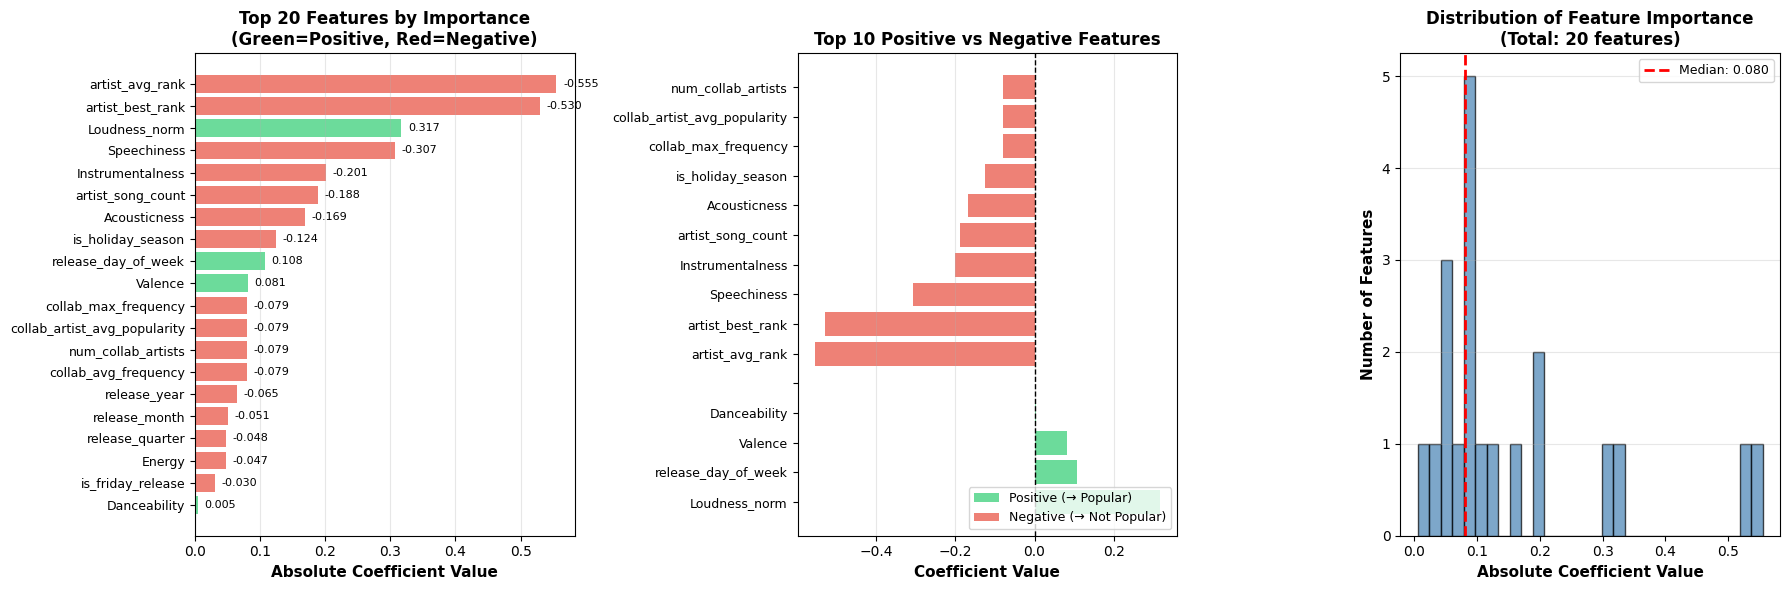

In [22]:

print("FEATURE IMPORTANCE ANALYSIS: SVM LINEAR MODELS")


# Get the final recommended model
final_model_baseline = best_models[('Baseline', 'SVM (Linear)')][0]
final_model_pca = best_models[('PCA', 'SVM (Linear)')][0]

print("SVM BASELINE - FEATURE IMPORTANCE (Coefficient Weights)")


# Extract coefficients
baseline_coefs = final_model_baseline.coef_[0]  # Shape: (n_features,)
baseline_feature_names = X_train_baseline.columns.tolist()

# Create DataFrame
baseline_importance_df = pd.DataFrame({
    'Feature': baseline_feature_names,
    'Coefficient': baseline_coefs,
    'Abs_Coefficient': np.abs(baseline_coefs)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 15 Most Important Features (Baseline):")
print("-" * 80)
display(baseline_importance_df.head(15))



fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax1 = axes[0]
top20_baseline = baseline_importance_df.head(20).copy()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top20_baseline['Coefficient']]

ax1.barh(range(len(top20_baseline)), top20_baseline['Abs_Coefficient'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(top20_baseline)))
ax1.set_yticklabels(top20_baseline['Feature'], fontsize=9)
ax1.set_xlabel('Absolute Coefficient Value', fontsize=11, weight='bold')
ax1.set_title('Top 20 Features by Importance\n(Green=Positive, Red=Negative)', fontsize=12, weight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(top20_baseline.iterrows()):
    ax1.text(row['Abs_Coefficient'] + 0.01, i, f"{row['Coefficient']:.3f}", 
             va='center', fontsize=8)


ax2 = axes[1]
positive_features = baseline_importance_df[baseline_importance_df['Coefficient'] > 0].head(10)
negative_features = baseline_importance_df[baseline_importance_df['Coefficient'] < 0].head(10)

y_pos_positive = np.arange(len(positive_features))
y_pos_negative = np.arange(len(negative_features))

ax2.barh(y_pos_positive, positive_features['Coefficient'], color='#2ecc71', alpha=0.7, label='Positive (→ Popular)')
ax2.barh(y_pos_negative + len(positive_features) + 1, negative_features['Coefficient'], 
         color='#e74c3c', alpha=0.7, label='Negative (→ Not Popular)')

all_labels = list(positive_features['Feature']) + [''] + list(negative_features['Feature'])
ax2.set_yticks(range(len(all_labels)))
ax2.set_yticklabels(all_labels, fontsize=9)
ax2.set_xlabel('Coefficient Value', fontsize=11, weight='bold')
ax2.set_title('Top 10 Positive vs Negative Features', fontsize=12, weight='bold')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(axis='x', alpha=0.3)

# --- Plot 3: Feature Importance Distribution ---
ax3 = axes[2]
ax3.hist(baseline_importance_df['Abs_Coefficient'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Absolute Coefficient Value', fontsize=11, weight='bold')
ax3.set_ylabel('Number of Features', fontsize=11, weight='bold')
ax3.set_title(f'Distribution of Feature Importance\n(Total: {len(baseline_importance_df)} features)', 
              fontsize=12, weight='bold')
ax3.axvline(x=baseline_importance_df['Abs_Coefficient'].median(), color='red', 
            linestyle='--', linewidth=2, label=f'Median: {baseline_importance_df["Abs_Coefficient"].median():.3f}')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
